<div class="jumbotron text-left"><b>
    
This tutorial describes how to use de DesignSpace within the SMT toolbox.
<div>
    
    February 2026 - `SMT version 2.10.1`
  
     Paul Saves (IRIT/SMAC), Jasper Bussemaker (DLR), Rémi Lafage (ONERA/DTIS/MIDL) and Nathalie BARTOLI (ONERA/DTIS/M2CI)

<div class="alert alert-info fade in" id="d110">
<p>Some updates</p>
<ol> -  Manipulation of mixed DOE (continuous, integer,  categorical and hierarchical variables) </ol>
</div>

<p class="alert alert-success" style="padding:1em">
To use SMT models, please follow this link : https://github.com/SMTorg/SMT/blob/master/README.md. The documentation is available here: http://smt.readthedocs.io/en/latest/
</p>

The reference paper is available
here https://www.sciencedirect.com/science/article/pii/S096599782300162X



For mixed integer with continuous relaxation, the reference paper is available here https://www.sciencedirect.com/science/article/pii/S0925231219315619

In [1]:
# to have the latest version
!pip install configspace
!pip install adsg-core
!pip install smt-design-space-ext
!pip install smt
!pip install "adsg-core[nb]"


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


<div class="alert alert-warning" >
If you use hierarchical variables and the size of your doe greater than 30 points, you may leverage the `numba` JIT compiler to speed up the computation
To do so:
    
 - install numba library
    
     `pip install numba`
    
    
 - and define the environment variable `USE_NUMBA_JIT = 1` (unset or 0 if you do not want to use numba)
    
     - Linux: export USE_NUMBA_JIT = 1
    
     - Windows: set USE_NUMBA_JIT = 1

</div>

In [2]:
%matplotlib inline

# to ignore warning messages
import warnings

import plotly.io as pio
from smt.sampling_methods import LHS
from smt_design_space_ext import (
    AdsgDesignSpaceImpl,
    CategoricalVariable,
    ConfigSpaceDesignSpaceImpl,
    DesignSpace,
    FloatVariable,
    IntegerVariable,
    OrdinalVariable,
)

warnings.filterwarnings("ignore")

pio.renderers.default = "notebook"

# MAELIA

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from smt.design_space import FloatVariable, OrdinalVariable
from smt_design_space_ext import AdsgDesignSpaceImpl
from smt.surrogate_models import KRG

# ==========================================
# 1. TERRAINSA PARAMETER SPACE
# ==========================================
# Tillage operations are represented by their explicit working depths.
# The fertiliser product is fixed to ammonium nitrate (AN).
FERTILISER_TYPE = "AN"
FIRST_PREPARATION_TYPE = "travail_sol_1"
SECOND_PREPARATION_TYPE = "une_reprise"
SOWING_OPERATION_TYPE = "semis"
TILLAGE_DEPTH_MIN_CM = 1.0
TILLAGE_DEPTH_MAX_CM = 25.0
SOWING_DEPTH_MIN_CM = 1.0
SOWING_DEPTH_MAX_CM = 4.0

SMT_FEATURES = [
    "Number_Of_Fertilisations",
    "Soil_Preparation_Performed",
    "Number_Of_Preparations",
    "Sowing_Date",
    "Preparation_To_Sowing_Delay",
    "Sowing_Depth",
    "First_Tillage_Depth",
    "Second_Tillage_Depth",
    "First_Fertilisation_Date",
    "Second_Fertilisation_Date",
    "Third_Fertilisation_Date",
    "Harvest_Date",
    "First_Fertilisation_Dose",
    "Second_Fertilisation_Dose",
    "Third_Fertilisation_Dose",
]
SMT_CATEGORICAL = [
    "Number_Of_Fertilisations",
    "Soil_Preparation_Performed",
    "Number_Of_Preparations",
]
SMT_CONTINUOUS = [
    feature for feature in SMT_FEATURES if feature not in SMT_CATEGORICAL
]

agri_design_space = AdsgDesignSpaceImpl(
    design_variables=[
        OrdinalVariable(["0_ferti", "1_ferti", "2_ferti", "3_ferti"]),
        
        OrdinalVariable(["0_prepa", "1_prepa", "2_prepa"]),
        FloatVariable(45, 106),
        FloatVariable(-44, -4),
        FloatVariable(SOWING_DEPTH_MIN_CM, SOWING_DEPTH_MAX_CM),
        FloatVariable(TILLAGE_DEPTH_MIN_CM, TILLAGE_DEPTH_MAX_CM),
        FloatVariable(TILLAGE_DEPTH_MIN_CM, TILLAGE_DEPTH_MAX_CM),
        FloatVariable(106, 323),
        FloatVariable(210, 323),
        FloatVariable(240, 323),
        FloatVariable(323, 384),
        FloatVariable(0, 2),
        FloatVariable(0, 2),
        FloatVariable(0, 2),
    ]
)

# ==========================================
# 2. HIERARCHICAL ACTIVATION RULES
# ==========================================
# Soil-preparation variables are active only when at least one tillage occurs.
agri_design_space.declare_decreed_var(
    decreed_var=3, meta_var=1, meta_value=["1_prepa", "2_prepa"]
)
agri_design_space.declare_decreed_var(
    decreed_var=5, meta_var=1, meta_value=["1_prepa", "2_prepa"]
)
agri_design_space.declare_decreed_var(
    decreed_var=6, meta_var=1, meta_value=["2_prepa"]
)

# Fertilisation dates and doses are activated by the number of applications.
agri_design_space.declare_decreed_var(
    decreed_var=7, meta_var=0, meta_value=["1_ferti", "2_ferti", "3_ferti"]
)
agri_design_space.declare_decreed_var(
    decreed_var=11, meta_var=0, meta_value=["1_ferti", "2_ferti", "3_ferti"]
)
agri_design_space.declare_decreed_var(
    decreed_var=8, meta_var=0, meta_value=["2_ferti", "3_ferti"]
)
agri_design_space.declare_decreed_var(
    decreed_var=12, meta_var=0, meta_value=["2_ferti", "3_ferti"]
)
agri_design_space.declare_decreed_var(
    decreed_var=9, meta_var=0, meta_value=["3_ferti"]
)
agri_design_space.declare_decreed_var(
    decreed_var=13, meta_var=0, meta_value=["3_ferti"]
)

DEFAULT_FLOATS = [
    75.0, -20.0, 3.0, 15.0, 10.0,
    150.0, 230.0, 280.0, 350.0,
    1.699, 1.699, 1.699,
]


def parse_smt_row(row_data):
    """Decode one SMT row while preserving the compact terrainSA hierarchy."""
    parsed = {
        "Number_Of_Fertilisations": 0,
        "Soil_Preparation_Performed": False,
        "Number_Of_Preparations": 1,
        "floats": [],
    }
    values = list(row_data.values()) if isinstance(row_data, dict) else row_data
    for value in values:
        if isinstance(value, (float, int, np.floating, np.integer)):
            parsed["floats"].append(float(value))
        elif isinstance(value, str):
            if value in ["0_ferti", "1_ferti", "2_ferti", "3_ferti"]:
                parsed["Number_Of_Fertilisations"] = int(value[0])
            elif value in ["Oui_prepa", "Non_prepa"]:
                parsed["Soil_Preparation_Performed"] = value == "Oui_prepa"
            elif value in ["0_prepa", "1_prepa", "2_prepa"]:
                parsed["Number_Of_Preparations"] = int(value[0])
    return parsed


def normalized_floats(parsed):
    floats = list(parsed["floats"])
    for default in DEFAULT_FLOATS[len(floats):]:
        floats.append(default)
    return floats[:len(DEFAULT_FLOATS)]


def ordered_fertilisation_dates(parsed, floats):
    dates = {"first": None, "second": None, "third": None}
    n_fertilisations = parsed["Number_Of_Fertilisations"]
    if n_fertilisations >= 1:
        dates["first"] = int(round(floats[5]))
    if n_fertilisations >= 2:
        dates["second"] = max(int(round(floats[6])), dates["first"] + 1)
    if n_fertilisations >= 3:
        dates["third"] = max(int(round(floats[7])), dates["second"] + 1)
    return dates


def extract_table_from_smt(x_array, dsg_space):
    rows = []
    decoded_data = dsg_space.decode_values(x_array)
    for row_data in decoded_data:
        parsed = parse_smt_row(row_data)
        floats = normalized_floats(parsed)
        fertilisation_dates = ordered_fertilisation_dates(parsed, floats)
        sowing_date = int(round(floats[0]))
        preparation_performed = parsed["Soil_Preparation_Performed"]
        n_preparations = parsed["Number_Of_Preparations"]
        n_fertilisations = parsed["Number_Of_Fertilisations"]

        rows.append({
            "Number_Of_Fertilisations": n_fertilisations,
            "Soil_Preparation_Performed": "Yes" if preparation_performed else "No",
            "Number_Of_Preparations": n_preparations if preparation_performed else "-",
            "Sowing_Date": sowing_date,
            "Preparation_To_Sowing_Delay": round(floats[1], 1) if preparation_performed else "-",
            "Sowing_Depth": round(floats[2], 1),
            "First_Tillage_Depth": round(floats[3], 1) if preparation_performed else "-",
            "Second_Tillage_Depth": (
                round(floats[4], 1)
                if preparation_performed and n_preparations == 2
                else "-"
            ),
            "First_Fertilisation_Date": fertilisation_dates["first"] or "-",
            "Second_Fertilisation_Date": fertilisation_dates["second"] or "-",
            "Third_Fertilisation_Date": fertilisation_dates["third"] or "-",
            "Harvest_Date": int(round(floats[8])),
            "First_Fertilisation_Dose": round(10 ** floats[9], 1) if n_fertilisations >= 1 else "-",
            "Second_Fertilisation_Dose": round(10 ** floats[10], 1) if n_fertilisations >= 2 else "-",
            "Third_Fertilisation_Dose": round(10 ** floats[11], 1) if n_fertilisations >= 3 else "-",
            "Fixed_Fertiliser": FERTILISER_TYPE,
        })
    return pd.DataFrame(rows)


def evaluate_maelia_dummy(x_array, dsg_space):
    """Illustrative response used only to demonstrate the SMT workflow."""
    y = np.zeros((x_array.shape[0], 1))
    decoded_data = dsg_space.decode_values(x_array)
    for i, row_data in enumerate(decoded_data):
        parsed = parse_smt_row(row_data)
        floats = normalized_floats(parsed)
        n_fertilisations = parsed["Number_Of_Fertilisations"]
        total_dose = 0.0
        if n_fertilisations >= 1:
            total_dose += 10 ** floats[9]
        if n_fertilisations >= 2:
            total_dose += 10 ** floats[10]
        if n_fertilisations >= 3:
            total_dose += 10 ** floats[11]
        y[i, 0] = 50 + (total_dose * 0.25) - (0.0006 * total_dose**2) + 0.1
    return y


In [4]:
N_DOE = 30  # Small demonstration sample; increase when needed.
print(f"Generating {N_DOE} hierarchical LHS points (SMT ADSG)...")

from smt.applications.mixed_integer import MixedIntegerSamplingMethod
from smt.sampling_methods import LHS

sampler = MixedIntegerSamplingMethod(
    LHS,
    agri_design_space,
    criterion="ese",
    seed=42,
)

xt_raw = sampler(N_DOE)
xt, _ = agri_design_space.correct_get_acting(xt_raw)

def is_new(row, array, tol=1e-8):
    return not any(np.allclose(row, existing, atol=tol) for existing in array)

xt_unique = []
for row in xt:
    if is_new(row, xt_unique):
        xt_unique.append(row)

xt = np.array(xt_unique)

if xt.shape[0] < N_DOE:
    print(f"{N_DOE - xt.shape[0]} duplicates found after hierarchical correction.")

while xt.shape[0] < N_DOE:
    n_missing = N_DOE - xt.shape[0]
    xt_new = sampler(n_missing * 2)
    xt_corrected, _ = agri_design_space.correct_get_acting(xt_new)

    for row in xt_corrected:
        if is_new(row, xt):
            xt = np.vstack([xt, row])
        if xt.shape[0] >= N_DOE:
            break

xt, _ = agri_design_space.correct_get_acting(xt)
print(f"DOE matrix: {xt.shape[0]} × {xt.shape[1]} variables\n")


Generating 30 hierarchical LHS points (SMT ADSG)...


DOE matrix: 30 × 14 variables



In [5]:
doe_display = extract_table_from_smt(xt, agri_design_space)
display(doe_display.iloc[:, :10])
display(doe_display.iloc[:, 10:])

yt = evaluate_maelia_dummy(xt, agri_design_space)

,Number_Of_Fertilisations,Soil_Preparation_Performed,Number_Of_Preparations,Sowing_Date,Preparation_To_Sowing_Delay,Sowing_Depth,First_Tillage_Depth,Second_Tillage_Depth,First_Fertilisation_Date,Second_Fertilisation_Date
0,2,No,-,81,-,1.7,-,-,247,308
1,0,No,-,96,-,3.0,-,-,-,-
2,2,No,-,83,-,2.6,-,-,233,261
3,0,No,-,95,-,1.7,-,-,-,-
4,2,No,-,47,-,2.5,-,-,191,220
5,1,No,-,100,-,1.3,-,-,201,-
6,0,No,-,67,-,2.2,-,-,-,-
7,2,No,-,99,-,3.6,-,-,289,290
8,2,No,-,62,-,3.4,-,-,286,321
9,1,No,-,87,-,1.9,-,-,192,-


,Third_Fertilisation_Date,Harvest_Date,First_Fertilisation_Dose,Second_Fertilisation_Dose,Third_Fertilisation_Dose,Fixed_Fertiliser
0,-,357,18.3,73.4,-,AN
1,-,383,-,-,-,AN
2,-,343,18.8,57.2,-,AN
3,-,357,-,-,-,AN
4,-,330,74.6,98.3,-,AN
5,-,358,58.4,-,-,AN
6,-,370,-,-,-,AN
7,-,342,64.9,72.8,-,AN
8,-,323,69.2,66.7,-,AN
9,-,349,61.1,-,-,AN


=== SMT DESIGN-SPACE GRAPH ===


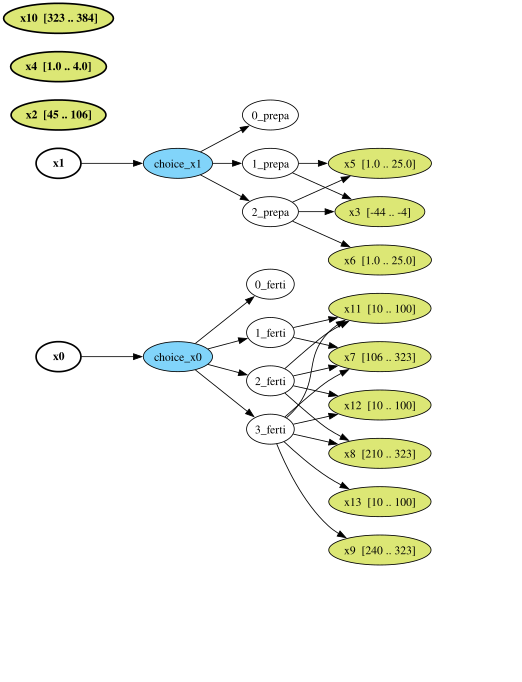

In [6]:
from graphviz import Source
from IPython.display import display

def render_to_image(dsg_obj, filename="temp_graph"):
    dot_str = dsg_obj.export_dot()
    layout_config = """
    graph [
        rankdir=LR,
        nodesep=0.3,
        ranksep=0.5,
        splines=true,
        margin=0
    ];
    """
    dot_str = dot_str.replace("{", "{\n" + layout_config, 1)
    src = Source(dot_str, filename=filename, format="png", engine="dot")
    src.render(cleanup=True)
    display(src)

print("=== SMT DESIGN-SPACE GRAPH ===")
render_to_image(agri_design_space.adsg, "maelia_space")


=== EXPLICIT MAELIA HIERARCHICAL DESIGN SPACE ===


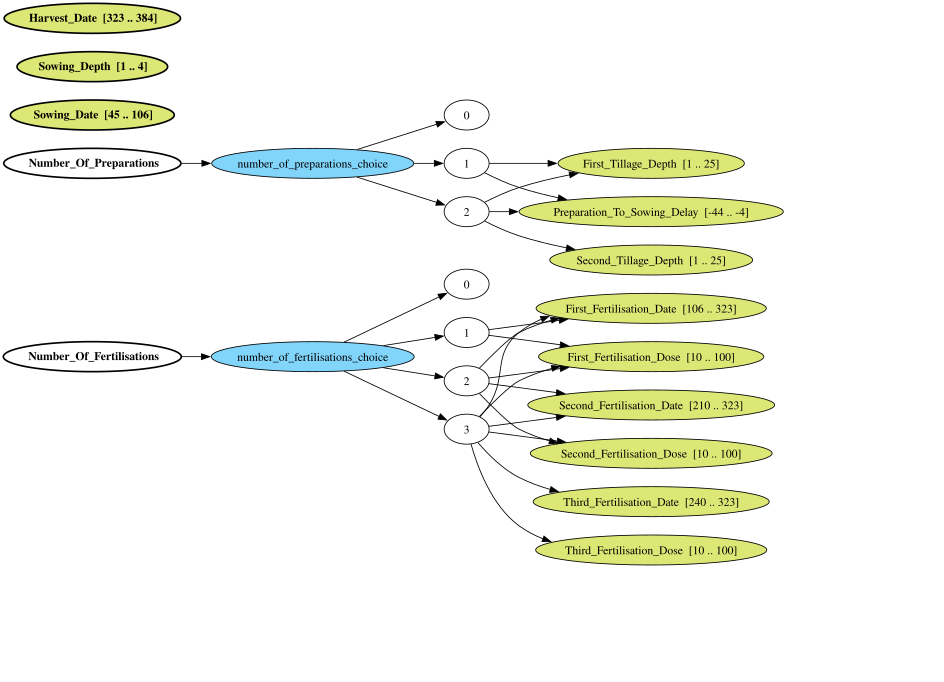

In [7]:
from adsg_core import BasicADSG, DesignVariableNode, NamedNode
from graphviz import Source
from IPython.display import display


def create_explicit_maelia_adsg():
    adsg = BasicADSG()

    # Root decisions (always active)
    n_fertilisations = NamedNode("Number_Of_Fertilisations")
    n_fertilisation_options = [
        NamedNode("0"), NamedNode("1"), NamedNode("2"), NamedNode("3")
    ]
    adsg.add_selection_choice(
        "number_of_fertilisations_choice",
        n_fertilisations,
        n_fertilisation_options,
    )

    n_preparations = NamedNode("Number_Of_Preparations")
    preparation_options = [NamedNode("0"), NamedNode("1"), NamedNode("2")]
    adsg.add_selection_choice(
        "number_of_preparations_choice",
        n_preparations,
        preparation_options,
    )

    sowing_date = DesignVariableNode("Sowing_Date", bounds=(45, 106))
    sowing_depth = DesignVariableNode("Sowing_Depth", bounds=(1, 4))
    harvest_date = DesignVariableNode("Harvest_Date", bounds=(323, 384))

    adsg.add_node(sowing_date)
    adsg.add_node(sowing_depth)
    adsg.add_node(harvest_date)

    # Soil-preparation hierarchy: active when at least one tillage occurs.
    preparation_delay = DesignVariableNode(
        "Preparation_To_Sowing_Delay", bounds=(-44, -4)
    )
    first_tillage_depth = DesignVariableNode(
        "First_Tillage_Depth", bounds=(1, 25)
    )
    for option_index in [1, 2]:
        for node in [preparation_delay, first_tillage_depth]:
            adsg.add_edge(preparation_options[option_index], node)

    second_tillage_depth = DesignVariableNode(
        "Second_Tillage_Depth", bounds=(1, 25)
    )
    adsg.add_edge(preparation_options[2], second_tillage_depth)

    # Fertilisation hierarchy; the fertiliser product is fixed to AN.
    first_fertilisation_date = DesignVariableNode(
        "First_Fertilisation_Date", bounds=(106, 323)
    )
    first_fertilisation_dose = DesignVariableNode(
        "First_Fertilisation_Dose", bounds=(0, 2)
    )
    for option_index in [1, 2, 3]:
        for node in [first_fertilisation_date, first_fertilisation_dose]:
            adsg.add_edge(n_fertilisation_options[option_index], node)

    second_fertilisation_date = DesignVariableNode(
        "Second_Fertilisation_Date", bounds=(210, 323)
    )
    second_fertilisation_dose = DesignVariableNode(
        "Second_Fertilisation_Dose", bounds=(0, 2)
    )
    for option_index in [2, 3]:
        for node in [second_fertilisation_date, second_fertilisation_dose]:
            adsg.add_edge(n_fertilisation_options[option_index], node)

    third_fertilisation_date = DesignVariableNode(
        "Third_Fertilisation_Date", bounds=(240, 323)
    )
    third_fertilisation_dose = DesignVariableNode(
        "Third_Fertilisation_Dose", bounds=(0, 2)
    )
    for node in [third_fertilisation_date, third_fertilisation_dose]:
        adsg.add_edge(n_fertilisation_options[3], node)

    return adsg.set_start_nodes({
        n_fertilisations,
        n_preparations,
        sowing_date,
        sowing_depth,
        harvest_date,
    })


def render_to_image(dsg_obj, filename="temp_graph"):
    dot_str = dsg_obj.export_dot()
    layout_config = """
    graph [
        rankdir=LR,
        nodesep=0.3,
        ranksep=0.5,
        splines=true,
        margin=0
    ];
    """
    dot_str = dot_str.replace("{", "{\n" + layout_config, 1)
    src = Source(dot_str, filename=filename, format="png", engine="dot")
    src.render(cleanup=True)
    display(src)


maelia_adsg = create_explicit_maelia_adsg()
print("=== EXPLICIT MAELIA HIERARCHICAL DESIGN SPACE ===")
render_to_image(maelia_adsg, "maelia_adsg")


In [8]:
print("\nTraining the SMT hierarchical Kriging model (KRG)...")
sm = KRG(
    design_space=agri_design_space,
    print_global=False,
    noise0=[0.01],
    corr="pow_exp",
)
sm.set_training_values(xt, yt)
sm.train()
print("Model trained.")



Training the SMT hierarchical Kriging model (KRG)...


Model trained.


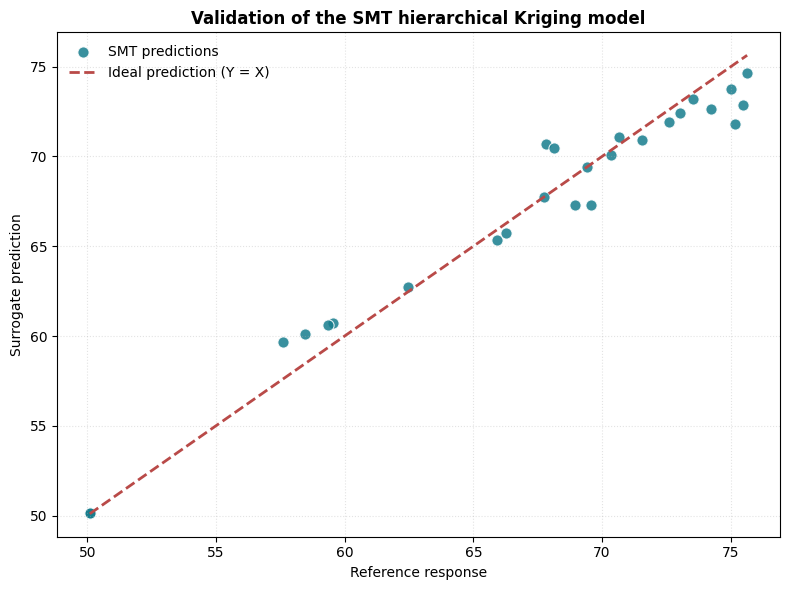

In [9]:
xtest, is_acting_test = agri_design_space._sample_valid_x(30)
y_test_true = evaluate_maelia_dummy(xtest, agri_design_space)
y_test_predicted = sm.predict_values(xtest)

plt.figure(figsize=(8, 6))
plt.scatter(
    y_test_true,
    y_test_predicted,
    color="#167D8D",
    edgecolors="white",
    linewidth=0.8,
    s=65,
    alpha=0.85,
    label="SMT predictions",
)
plt.plot(
    [y_test_true.min(), y_test_true.max()],
    [y_test_true.min(), y_test_true.max()],
    color="#B94A48",
    linestyle="--",
    linewidth=2,
    label="Ideal prediction (Y = X)",
)
plt.xlabel("Reference response")
plt.ylabel("Surrogate prediction")
plt.title("Validation of the SMT hierarchical Kriging model", fontweight="bold")
plt.legend(frameon=False)
plt.grid(True, linestyle=":", alpha=0.35)
plt.tight_layout()
plt.show()


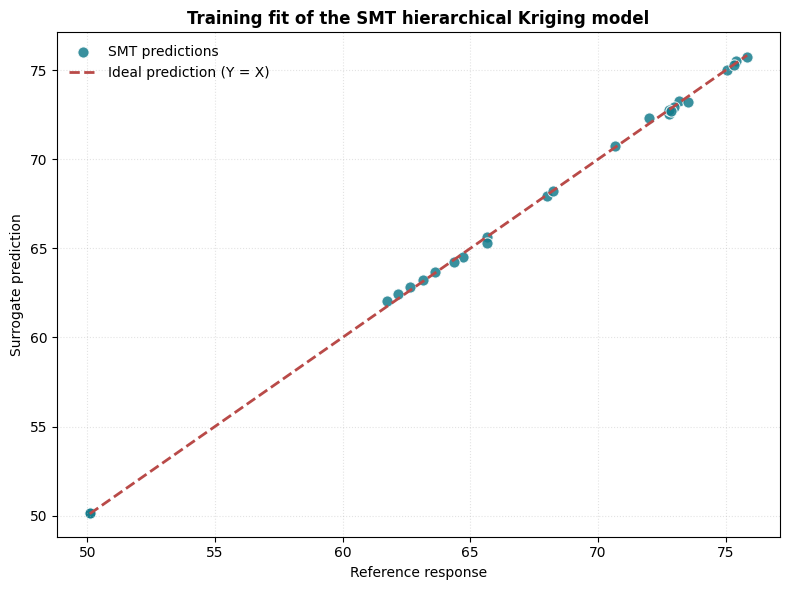

In [10]:
y_train_true = evaluate_maelia_dummy(xt, agri_design_space)
y_train_predicted = sm.predict_values(xt)

plt.figure(figsize=(8, 6))
plt.scatter(
    y_train_true,
    y_train_predicted,
    color="#167D8D",
    edgecolors="white",
    linewidth=0.8,
    s=65,
    alpha=0.85,
    label="SMT predictions",
)
plt.plot(
    [y_train_true.min(), y_train_true.max()],
    [y_train_true.min(), y_train_true.max()],
    color="#B94A48",
    linestyle="--",
    linewidth=2,
    label="Ideal prediction (Y = X)",
)
plt.xlabel("Reference response")
plt.ylabel("Surrogate prediction")
plt.title("Training fit of the SMT hierarchical Kriging model", fontweight="bold")
plt.legend(frameon=False)
plt.grid(True, linestyle=":", alpha=0.35)
plt.tight_layout()
plt.show()
